In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
n_paths = 10**4
n_steps = 10**4
T = 100
mu = 0.01
epsilon = 0.01
sqrt_epsilon = np.sqrt(epsilon)
def f(r):
    return np.pi-r

def wall_rep(r):
    return 1/r+1/(r-2*np.pi)

In [6]:
dt = T/n_steps
X_s = np.zeros((n_paths, n_steps+1))
X_s[:, 0] = np.pi
W_s = np.sqrt(dt) * np.random.normal(size=(n_paths, n_steps))

for i in range(n_steps):
    X_s[:, i+1] = X_s[:, i] + 2*mu*(f(X_s[:, i])+wall_rep(X_s[:, i]))*dt  + 2*sqrt_epsilon*W_s[:, i]


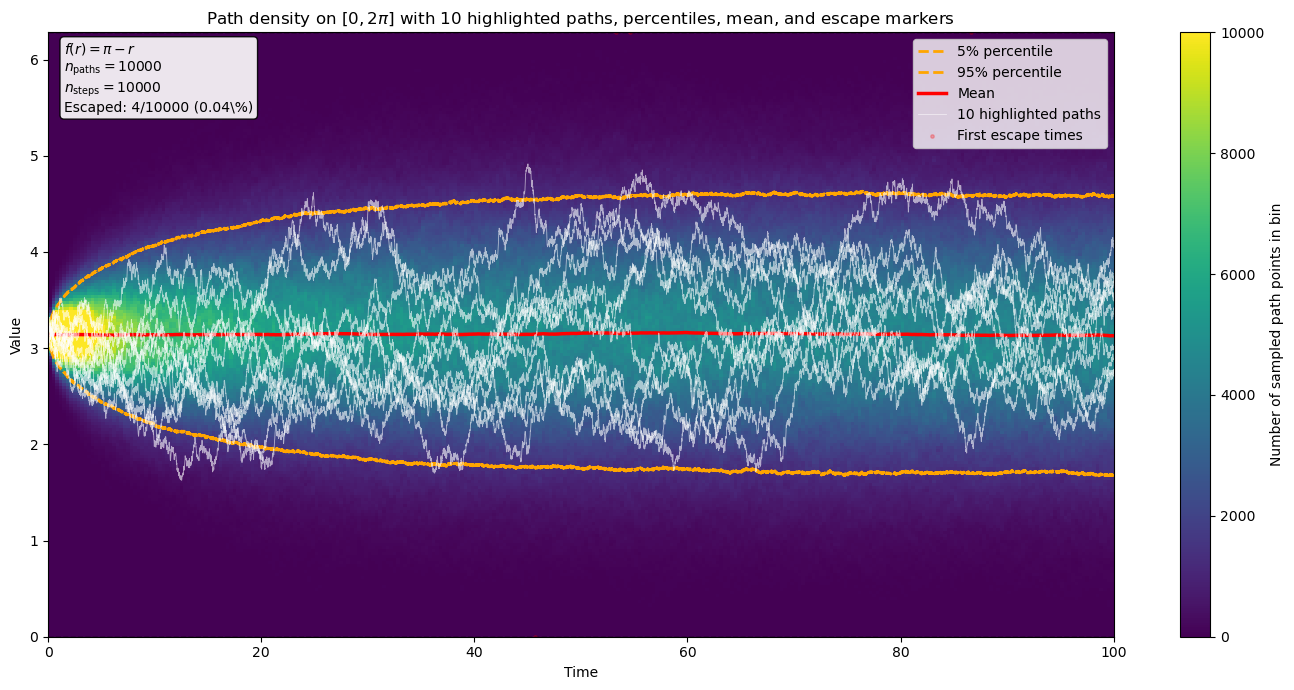

Escaped paths: 4 / 10000
Fraction escaped: 0.000400


In [7]:
# ============================================================
# PLOTTING ONLY
# Density plot in (time, value) on [0, 2pi], with 10 paths
# highlighted, 5%/95% percentile lines, mean line,
# and escape markers
# ============================================================

y_min, y_max = 0.0, 2 * np.pi

# ---------------------------------
# 1. Subsample in time for plotting
# ---------------------------------
n_time_plot = n_steps
time_idx = np.linspace(0, n_steps, n_time_plot, dtype=int)
t_plot = time_idx * dt
X_plot = X_s[:, time_idx]   # shape: (n_paths, n_time_plot)

# ---------------------------------
# 2. Detect escapes
# ---------------------------------
escaped_mask = np.any((X_s < y_min) | (X_s > y_max), axis=1)
escaped_ids = np.where(escaped_mask)[0]

first_escape_idx = np.full(n_paths, -1, dtype=int)
if escaped_ids.size > 0:
    first_escape_idx[escaped_ids] = np.argmax(
        (X_s[escaped_ids] < y_min) | (X_s[escaped_ids] > y_max), axis=1
    )
first_escape_time = np.where(first_escape_idx >= 0, first_escape_idx * dt, np.nan)

# ---------------------------------
# 3. Build density only for values inside [0, 2pi]
# ---------------------------------
in_box = (X_plot >= y_min) & (X_plot <= y_max)

# Flatten only the in-interval values
t_dense = np.broadcast_to(t_plot, X_plot.shape)[in_box]
x_dense = X_plot[in_box]

# ---------------------------------
# 4. Compute statistics inside [0, 2pi]
# ---------------------------------
X_stats = np.where(in_box, X_plot, np.nan)

mean_line = np.nanmean(X_stats, axis=0)
q05_line = np.nanpercentile(X_stats, 5, axis=0)
q95_line = np.nanpercentile(X_stats, 95, axis=0)

# ---------------------------------
# 5. Choose 10 random paths to highlight
# ---------------------------------
rng = np.random.default_rng(12345)
n_highlight = 10
highlight_ids = rng.choice(n_paths, size=min(n_highlight, n_paths), replace=False)

# ---------------------------------
# 6. Escape summary
# ---------------------------------
n_escaped = escaped_mask.sum()
escaped_pct = 100 * n_escaped / n_paths

# ---------------------------------
# 7. Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Density background
hb = ax.hist2d(
    t_dense,
    x_dense,
    bins=[300, 200],
    range=[[0, T], [y_min, y_max]],
    cmap="viridis",
    vmax=10000   # example cap
)
cbar = plt.colorbar(hb[3], ax=ax)
cbar.set_label("Number of sampled path points in bin")

# Boundary lines
ax.axhline(y_min, linestyle="--", linewidth=1, color="black")
ax.axhline(y_max, linestyle="--", linewidth=1, color="black")

# 5% and 95% percentile lines
ax.plot(t_plot, q05_line, linewidth=2.0, linestyle="--", color="orange", label="5% percentile")
ax.plot(t_plot, q95_line, linewidth=2.0, linestyle="--", color="orange", label="95% percentile")

# Mean line
ax.plot(t_plot, mean_line, linewidth=2.5, color="red", label="Mean")

# Highlight 10 random paths
for j, pid in enumerate(highlight_ids):
    path = X_plot[pid].copy()

    # Plot only the part inside [0, 2pi]
    path_in = np.where((path >= y_min) & (path <= y_max), path, np.nan)
    if j == 0:
        ax.plot(t_plot, path_in, linewidth=0.6, alpha=0.6, color="white", label="10 highlighted paths")
    else:
        ax.plot(t_plot, path_in, linewidth=0.6, alpha=0.6, color="white")

    # If this highlighted path escapes, mark first escape clearly
    fe_idx = first_escape_idx[pid]
    if fe_idx >= 0:
        fe_t = fe_idx * dt
        fe_val = X_s[pid, fe_idx]

        # Mark at the closest boundary for visibility
        marker_y = y_min if fe_val < y_min else y_max
        ax.scatter(
            [fe_t], [marker_y],
            marker="x", s=80, linewidths=2.0, color="red", zorder=5
        )
        ax.axvline(fe_t, color="red", alpha=0.12, linewidth=1)

# Mark first escape times for all escaped paths as a red rug on the boundary
if escaped_ids.size > 0:
    escape_boundary_y = np.where(
        X_s[escaped_ids, first_escape_idx[escaped_ids]] < y_min,
        y_min,
        y_max
    )
    ax.scatter(
        first_escape_time[escaped_ids],
        escape_boundary_y,
        s=6, color="red", alpha=0.25,
        label="First escape times"
    )

# Annotation box
info_text = (
    rf"$f(r)=\pi-r$" "\n"
    rf"$n_{{\mathrm{{paths}}}}={n_paths}$" "\n"
    rf"$n_{{\mathrm{{steps}}}}={n_steps}$" "\n"
    rf"Escaped: {n_escaped}/{n_paths} ({escaped_pct:.2f}\%)"
)
ax.text(
    0.015, 0.985, info_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

ax.set_xlim(0, T)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title(r"Path density on $[0,2\pi]$ with 10 highlighted paths, percentiles, mean, and escape markers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---------------------------------
# 8. Optional: print escape summary
# ---------------------------------
print(f"Escaped paths: {n_escaped} / {n_paths}")
print(f"Fraction escaped: {n_escaped / n_paths:.6f}")

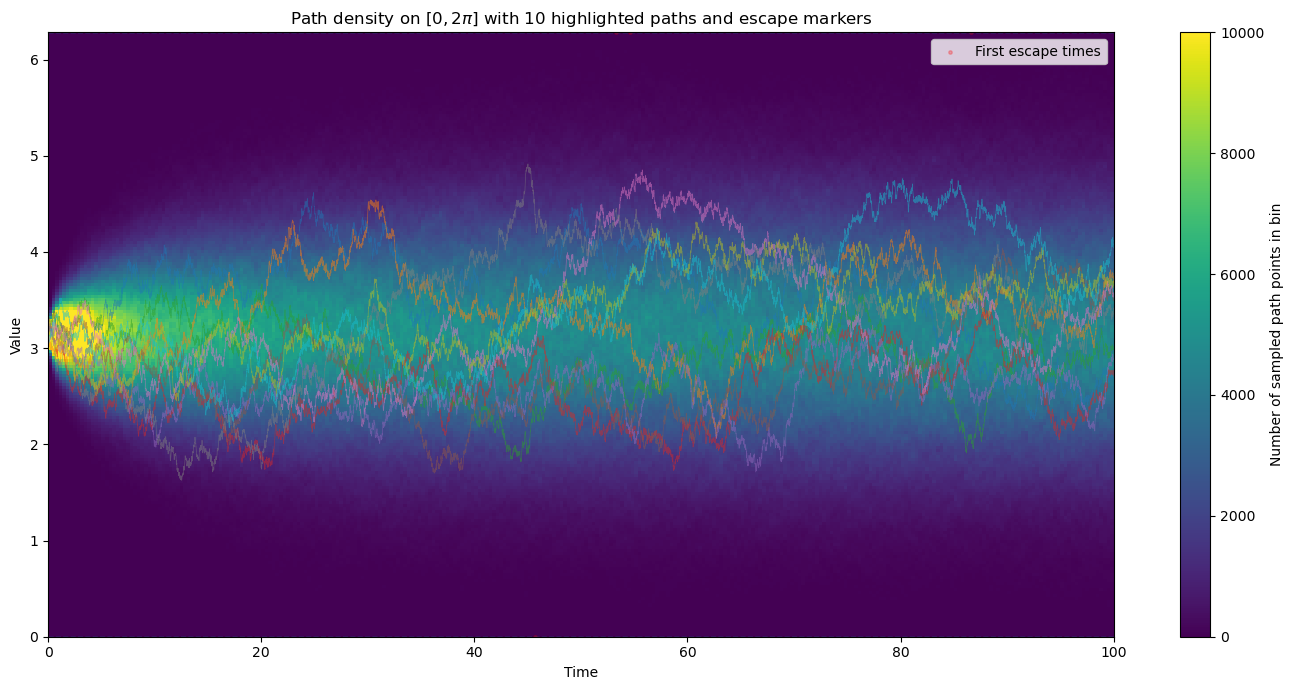

Escaped paths: 4 / 10000
Fraction escaped: 0.000400


In [8]:
# ============================================================
# PLOTTING ONLY
# Density plot in (time, value) on [0, 2pi], with 10 paths
# highlighted and escapes marked clearly
# ============================================================

y_min, y_max = 0.0, 2 * np.pi

# ---------------------------------
# 1. Subsample in time for plotting
# ---------------------------------
n_time_plot = n_steps
time_idx = np.linspace(0, n_steps, n_time_plot, dtype=int)
t_plot = time_idx * dt
X_plot = X_s[:, time_idx]   # shape: (n_paths, n_time_plot)

# ---------------------------------
# 2. Detect escapes
# ---------------------------------
escaped_mask = np.any((X_s < y_min) | (X_s > y_max), axis=1)
escaped_ids = np.where(escaped_mask)[0]

first_escape_idx = np.full(n_paths, -1, dtype=int)
if escaped_ids.size > 0:
    first_escape_idx[escaped_ids] = np.argmax(
        (X_s[escaped_ids] < y_min) | (X_s[escaped_ids] > y_max), axis=1
    )
first_escape_time = np.where(first_escape_idx >= 0, first_escape_idx * dt, np.nan)

# ---------------------------------
# 3. Build density only for values inside [0, 2pi]
# ---------------------------------
in_box = (X_plot >= y_min) & (X_plot <= y_max)

# Flatten only the in-interval values
t_dense = np.broadcast_to(t_plot, X_plot.shape)[in_box]
x_dense = X_plot[in_box]

# ---------------------------------
# 4. Choose 10 random paths to highlight
# ---------------------------------
rng = np.random.default_rng(12345)
n_highlight = 10
highlight_ids = rng.choice(n_paths, size=min(n_highlight, n_paths), replace=False)

# ---------------------------------
# 5. Plot
# ---------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Density background
hb = ax.hist2d(
    t_dense,
    x_dense,
    bins=[300, 200],
    range=[[0, T], [y_min, y_max]],
    cmap="viridis",
    vmax=10000   # example cap
)
cbar = plt.colorbar(hb[3], ax=ax)
cbar.set_label("Number of sampled path points in bin")

# Boundary lines
ax.axhline(y_min, linestyle="--", linewidth=1)
ax.axhline(y_max, linestyle="--", linewidth=1)

# Highlight 10 random paths
for pid in highlight_ids:
    path = X_plot[pid].copy()

    # Plot only the part inside [0, 2pi]
    path_in = np.where((path >= y_min) & (path <= y_max), path, np.nan)
    ax.plot(t_plot, path_in, linewidth=0.5, alpha=0.5)

    # If this highlighted path escapes, mark first escape clearly
    fe_idx = first_escape_idx[pid]
    if fe_idx >= 0:
        fe_t = fe_idx * dt
        fe_val = X_s[pid, fe_idx]

        # Mark at the closest boundary for visibility
        marker_y = y_min if fe_val < y_min else y_max
        ax.scatter(
            [fe_t], [marker_y],
            marker="x", s=80, linewidths=2.0, color="red", zorder=5
        )
        ax.axvline(fe_t, color="red", alpha=0.15, linewidth=1)

# Mark first escape times for all escaped paths as a red rug on the top boundary
if escaped_ids.size > 0:
    escape_boundary_y = np.where(
        X_s[escaped_ids, first_escape_idx[escaped_ids]] < y_min,
        y_min,
        y_max
    )
    ax.scatter(
        first_escape_time[escaped_ids],
        escape_boundary_y,
        s=6, color="red", alpha=0.25,
        label="First escape times"
    )

ax.set_xlim(0, T)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Path density on $[0,2\\pi]$ with 10 highlighted paths and escape markers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ---------------------------------
# 6. Optional: print escape summary
# ---------------------------------
n_escaped = escaped_mask.sum()
print(f"Escaped paths: {n_escaped} / {n_paths}")
print(f"Fraction escaped: {n_escaped / n_paths:.6f}")